In [1]:
import numpy as np # linear algebra
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("/kaggle/input/playground-series-s5e5/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e5/test.csv")


## Data Preprocessing


In [3]:
print("--- Dataset Head ---")
df.head()

--- Dataset Head ---


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [4]:
print("\n--- Missing Values Count ---")
print(df.isnull().sum())
print(test.isnull().sum())


--- Missing Values Count ---
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64


In [5]:
df.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [6]:
df.columns

Index(['id', 'Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')

### chekcing for null values and if there are any , it is filled with median or mean

In [7]:
colums =[  'Height', 'Weight', 'Duration', 'Heart_Rate','Body_Temp']
# if df.isnull().sum().sum() == 0:
#     print("No missing values found.")
# else:
    
    # for i in colums :
    #     df[i] = df[i].replace(np.inf, np.nan)
    #     df[i] = df[i].fillna(df[i].median())
    # df['Age']=df["Age"].fillna(df['Age'].mean())
    # print("Missing values handled.")

In [8]:
for i in colums :
    df[i] = df[i].replace(np.inf, np.nan)
    df[i] = df[i].fillna(df[i].median())
    df['Age']=df["Age"].fillna(df['Age'].mean())
    print("Missing values handled.")

Missing values handled.
Missing values handled.
Missing values handled.
Missing values handled.
Missing values handled.


### One hot encoding of gender column

In [9]:
df = pd.get_dummies(df, columns=['Sex'], drop_first=True,dtype = int)
test =pd.get_dummies(test, columns = ['Sex'], drop_first = True , dtype = int)
df.head()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Sex_male
0,0,36,189.0,82.0,26.0,101.0,41.0,150.0,1
1,1,64,163.0,60.0,8.0,85.0,39.7,34.0,0
2,2,51,161.0,64.0,7.0,84.0,39.8,29.0,0
3,3,20,192.0,90.0,25.0,105.0,40.7,140.0,1
4,4,38,166.0,61.0,25.0,102.0,40.6,146.0,0


### Scaling the numerical data 

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[colums] = scaler.fit_transform(df[colums])
test[colums] = scaler.transform(test[colums])

### FInding outliers

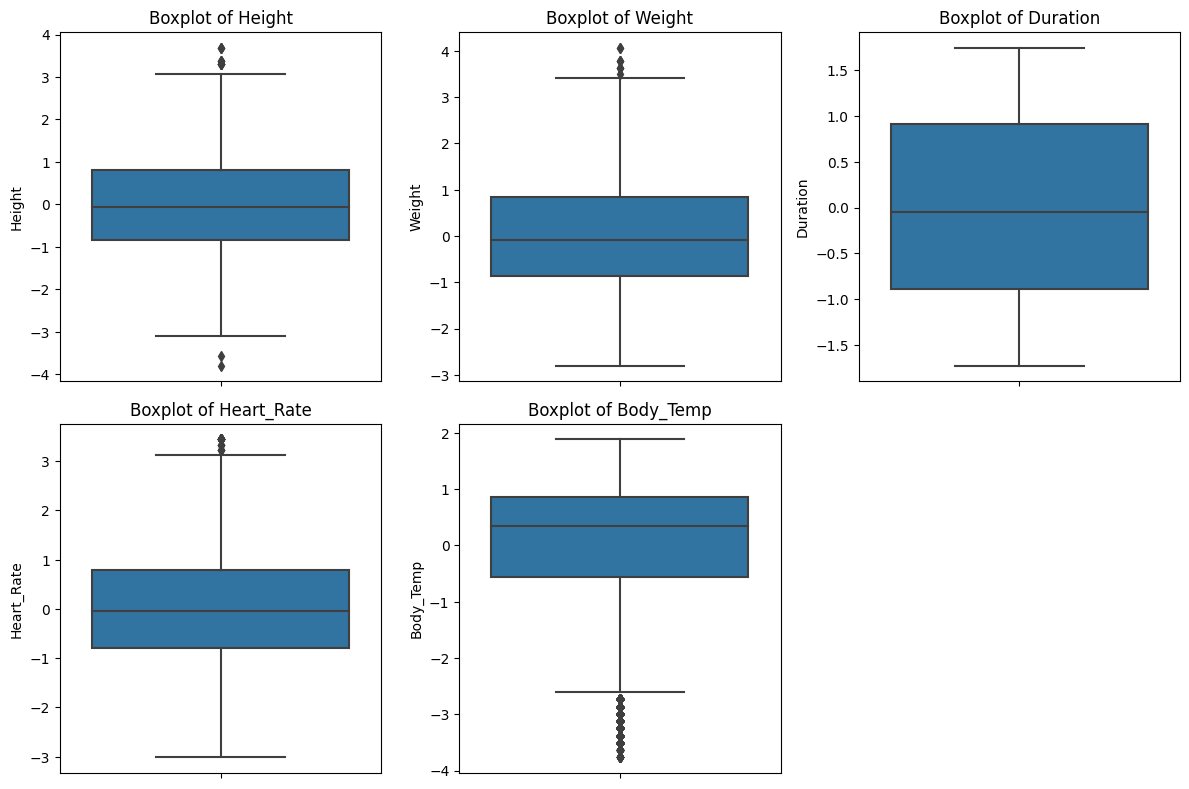

In [11]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(colums, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### removing outliers

In [12]:
for i in colums :
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3-Q1
    upper = Q3+1.5*IQR
    lower = Q1 - 1.5*IQR
    df[i]=df[i].clip(lower = lower , upper = upper)
Q1_cal = df["Calories"].quantile(0.25)
Q3_cal = df["Calories"].quantile(0.75)
IQR_cal = Q3-Q1
upper_cal = Q3_cal+1.5*IQR_cal
lower_cal = Q1_cal - 1.5*IQR_cal
df["Calories"]=df["Calories"].clip(lower = lower_cal , upper = upper_cal)

In [13]:
for i in colums :
    Q1 = test[i].quantile(0.25)
    Q3 = test[i].quantile(0.75)
    IQR = Q3-Q1
    upper = Q3+1.5*IQR
    lower = Q1 - 1.5*IQR
    test[i]=test[i].clip(lower = lower , upper = upper)

In [14]:
list (df.columns)

['id',
 'Age',
 'Height',
 'Weight',
 'Duration',
 'Heart_Rate',
 'Body_Temp',
 'Calories',
 'Sex_male']

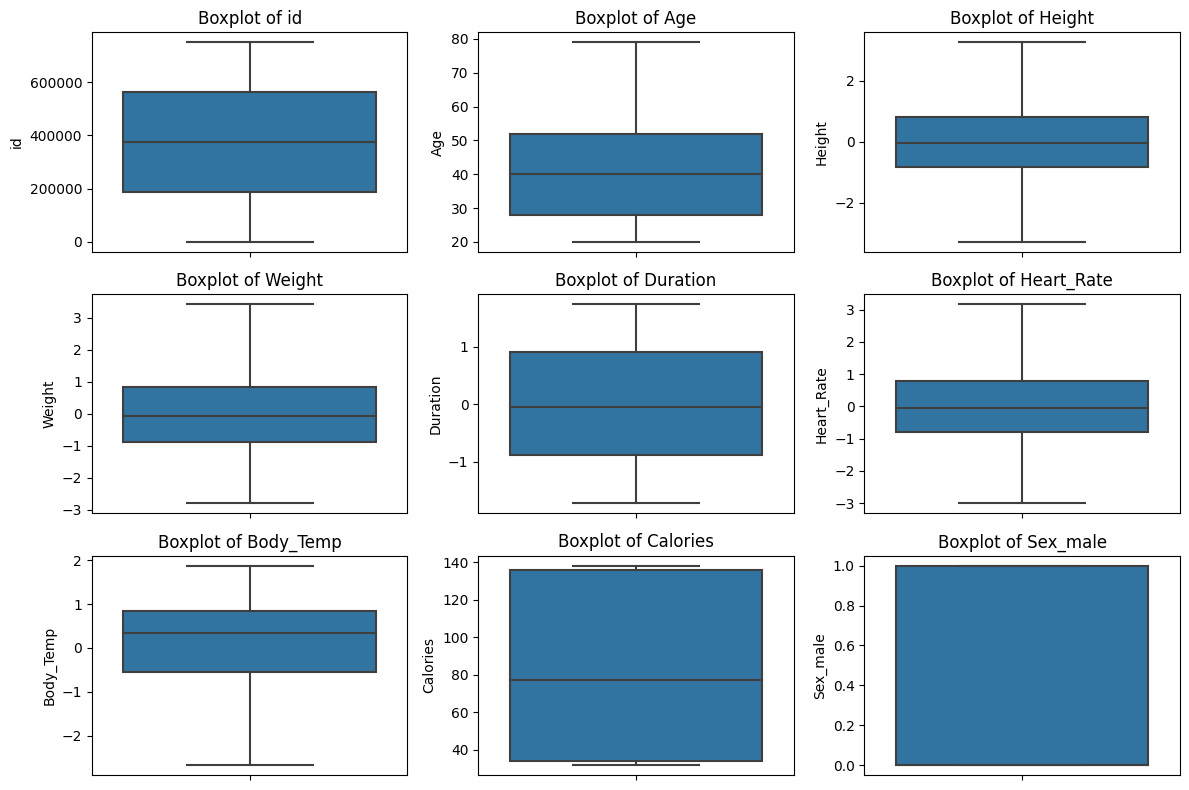

In [15]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(list (df.columns), 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [32]:
cleaned_df = pd.DataFrame(df)  
cleaned_df.to_csv('cleaned_data.csv', index=False)

## EDA 

### Calorie distrubition by sex

In [16]:
test.head(10)

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Sex_male
0,750000,45,0.179525,0.418684,-1.008011,-0.897793,-0.302938,1
1,750001,26,1.972969,1.562956,0.548113,0.583714,0.594643,1
2,750002,29,1.037259,0.704752,0.069306,0.689536,0.466417,0
3,750003,39,-0.210354,-0.153452,0.548113,1.218646,0.722869,0
4,750004,30,-0.132378,-0.582554,0.069306,-0.157039,0.594643,0
5,750005,43,-0.444282,-0.725587,-1.127713,-1.532724,-0.815841,0
6,750006,74,1.115235,1.562956,-0.768607,-1.003614,-0.046486,1
7,750007,60,0.881307,1.062337,-1.606520,-1.744368,-2.482777,1
8,750008,21,1.661066,1.133854,-1.367117,-1.215258,-1.713422,1
9,750009,32,1.115235,0.990820,1.625430,1.641933,0.979321,1


In [17]:
df= df.drop("id", axis = 1)
test.columns
test = test.drop("id",axis = 1)

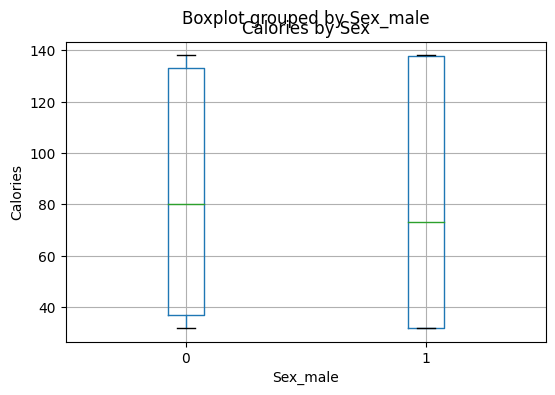


Mean Calories by Sex:
Sex_male
0    83.190678
1    81.374343
Name: Calories, dtype: float64


In [18]:
df.boxplot(column='Calories', by='Sex_male', figsize=(6,4))
plt.title('Calories by Sex')
plt.ylabel('Calories')
plt.show()

print("\nMean Calories by Sex:")
print(df.groupby('Sex_male')['Calories'].mean())

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

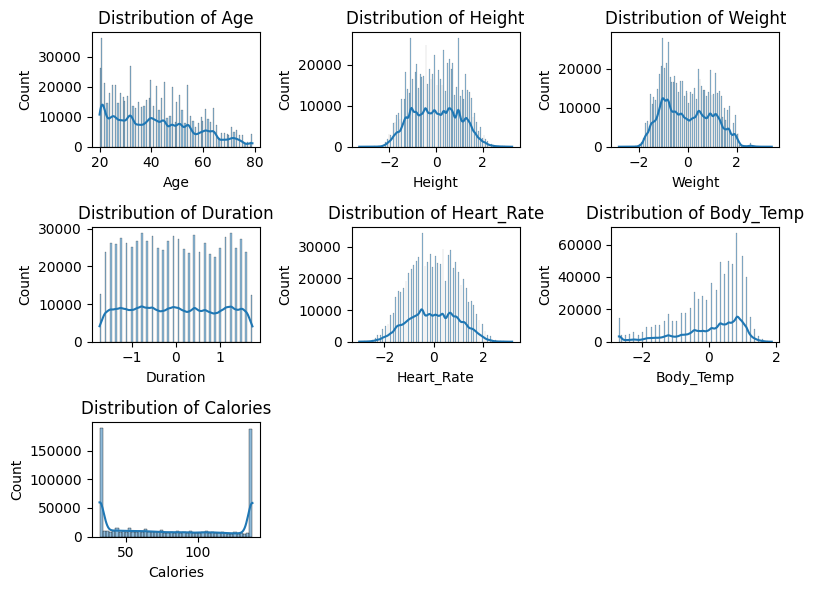


Skewness of Features:
Age           0.436397
Height        0.051734
Weight        0.211052
Duration      0.026259
Heart_Rate   -0.005996
Body_Temp    -0.941104
Calories      0.136944
dtype: float64


In [19]:
numerical_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']
plt.figure(figsize=(8,6))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Check skewness
print("\nSkewness of Features:")
print(df[numerical_cols].skew())

### Adding more features like BMI 

In [20]:
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
df['Sex_Weight'] = df['Sex_male'] * df['Weight']

test['BMI'] = test['Weight'] / (test['Height'] ** 2)

<Axes: >

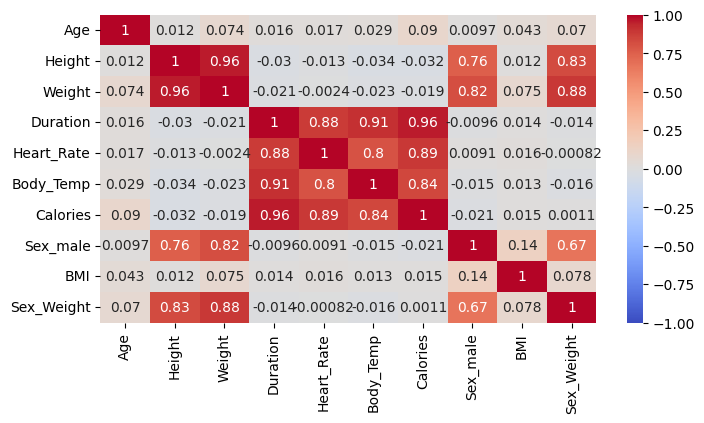

In [21]:
corr = df.corr()
plt.figure(figsize = (8,4) )
sns.heatmap(corr, annot=True, cmap='coolwarm',  vmin=-1, vmax=1)

In [22]:
df = df.drop(['Height', 'Sex_Weight'], axis=1)
test = test.drop(["Height"], axis = 1)
# to remove redunncy 

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


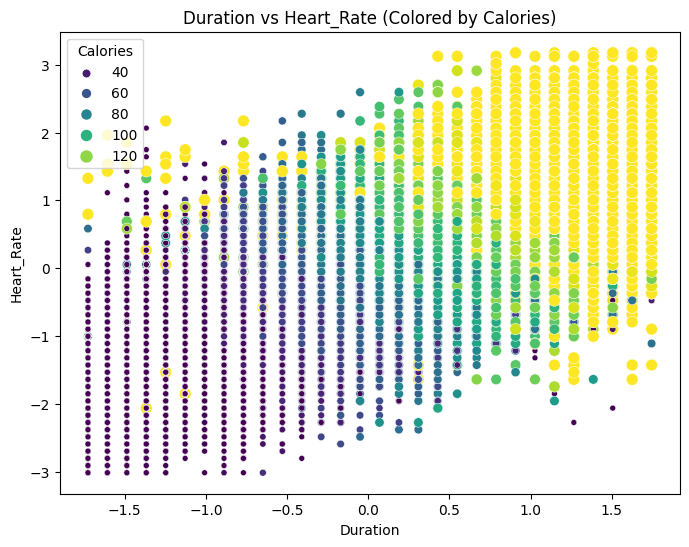

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Duration', y='Heart_Rate', hue='Calories', size='Calories', palette='viridis')
plt.title('Duration vs Heart_Rate (Colored by Calories)')
plt.show()

This suggests an interaction term (e.g., Duration * Heart_Rate) might be a useful feature to add.

In [24]:
df["Exercise_Intensity"] = df["Heart_Rate"] *df['Duration']
test["Exercise_Intensity"] = test["Heart_Rate"] *test['Duration']
new_cols = ['BMI', 'Exercise_Intensity']
df[new_cols] = scaler.fit_transform(df[new_cols])
test[new_cols] = scaler.transform(test[new_cols])

## Modelling

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df['Calories'] = scaler.fit_transform(df[['Calories']]) ### in histogram perivlsuy plotted, lot of skewness was observed 

2025-05-27 05:58:28.535967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748325508.724945      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748325508.780942      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [26]:
X = df.drop('Calories', axis=1)
y = df['Calories']

In [27]:
X_train , X_temp, y_train, y_temp  = train_test_split(X, y, test_size=0.3, random_state=42)
X_val,X_test , y_val,y_test  = train_test_split(X_temp, y_temp, test_size = 0.9, random_state = 42)
print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Training: (525000, 8), Validation: (22500, 8), Test: (202500, 8)


In [30]:


tf.random.set_seed(42)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Input layer + first hidden layer
    Dropout(0.2), 
    Dense(16, activation='relu'), 
    Dropout(0.2),
    Dense(16, activation='relu'), 
    Dense(1) 
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])  # Mean Absolute Error (MAE) for evaluation


model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,905 (7.44 KB)

 Trainable params: 1,905 (7.44 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, 
    batch_size=32, 
    verbose=1 
)

Epoch 1/50
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - loss: 0.3870 - mae: 0.3340 - val_loss: 0.0134 - val_mae: 0.0925
Epoch 2/50
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.0095 - mae: 0.0661 - val_loss: 0.0116 - val_mae: 0.0808
Epoch 3/50
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0077 - mae: 0.0578 - val_loss: 0.0185 - val_mae: 0.1123
Epoch 4/50
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0071 - mae: 0.0548 - val_loss: 0.0137 - val_mae: 0.0892
Epoch 5/50
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0068 - mae: 0.0530 - val_loss: 0.0155 - val_mae: 0.0936
Epoch 6/50
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.0066 - mae: 0.0521 - val_loss: 0.0124 - val_mae: 0.0809
Epoch 7/50
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0066 - mae: 0.0518 - val_loss: 0.0140 - val_mae: 0.0876
Epoch 8/50
16407/16407 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0065 - mae: 0.0513 - val_loss: 0.0173 - val_mae: 0.1019
Epoch 9/50
16407

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)